# Тесты со сгенерированными графами

In [66]:
import numpy as np
import osmnx as ox
import geopandas as gpd
import networkx as nx

import matplotlib.pyplot as plt

from graphs.algorithms import generate_grid_graph, remove_random_elements

# Пример 1. Простой квадратный граф

In [67]:
G = generate_grid_graph(n=100, m=100, step=100.0, speed=30.0)

## Расчет состояния прибытия

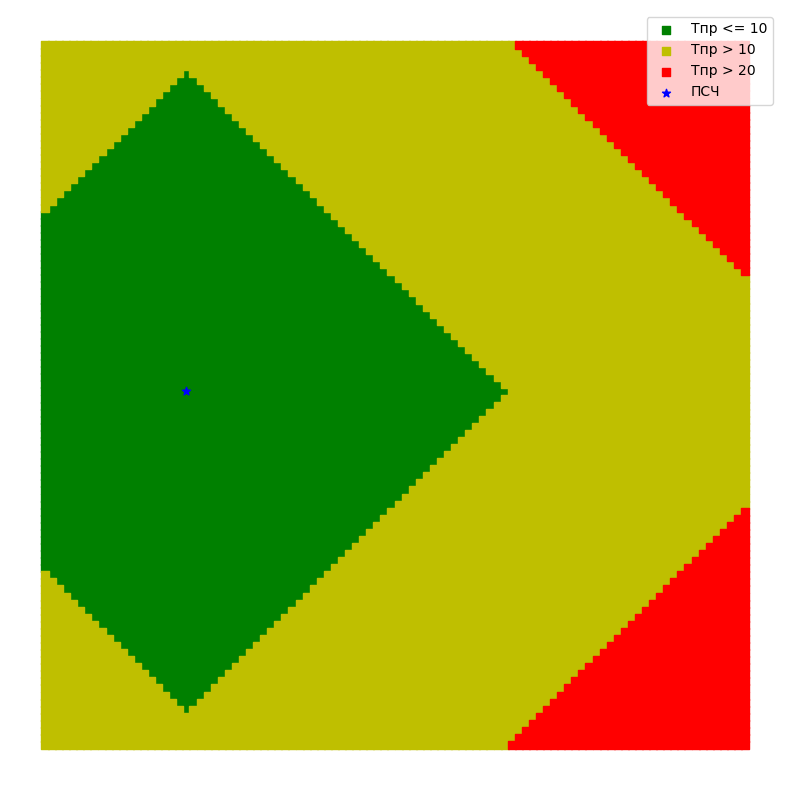

     Среднее время прибытия:  12.7 мин.
Максимальное время прибытия:  26.8 мин.
                      ИП-10:  35.16 %
                      ИП-10:  88.44 %


In [68]:
from genesis.states import FirstArrivalUnitState
from genesis.metrics import ArrivalTime, CoverIndex

units = {
    2050: 'ПСЧ-1',
    # 7020: 'ПСЧ-2',
    }

times, _ = FirstArrivalUnitState()(G, units)

g_nodes = ox.graph_to_gdfs(G, nodes=True, edges=False)
g_nodes['arrival_time'] = times

def print_results(g_nodes, units, figsize=(10,10)):
    # Печать карты
    fig, ax = plt.subplots(1,1, figsize=figsize)
    g_nodes.query('arrival_time<=10').plot(ax=ax, color='g', label='Тпр <= 10', marker='s', legend=True)
    g_nodes.query('arrival_time<=20 and arrival_time>10').plot(ax=ax, color='y', label='Тпр > 10', marker='s', legend=True)
    g_nodes.query('arrival_time>20').plot(ax=ax, color='r', label='Тпр > 20', marker='s', legend=True)
    g_nodes.loc[units.keys()].plot(ax=ax, color='b', label='ПСЧ', marker='*', legend=True)
    ax.axis('off')
    ax.legend()
    plt.show()

    # Печать метрик
    print('     Среднее время прибытия: ', round(ArrivalTime()(times), 1), 'мин.')
    print('Максимальное время прибытия: ', round(ArrivalTime(np.max)(times), 1), 'мин.')
    print('                      ИП-10: ', CoverIndex(10)(g_nodes['arrival_time']), '%')
    print('                      ИП-10: ', CoverIndex(20)(g_nodes['arrival_time']), '%')

print_results(g_nodes, units)

# Пример 2. Квадратный граф с диагоналями

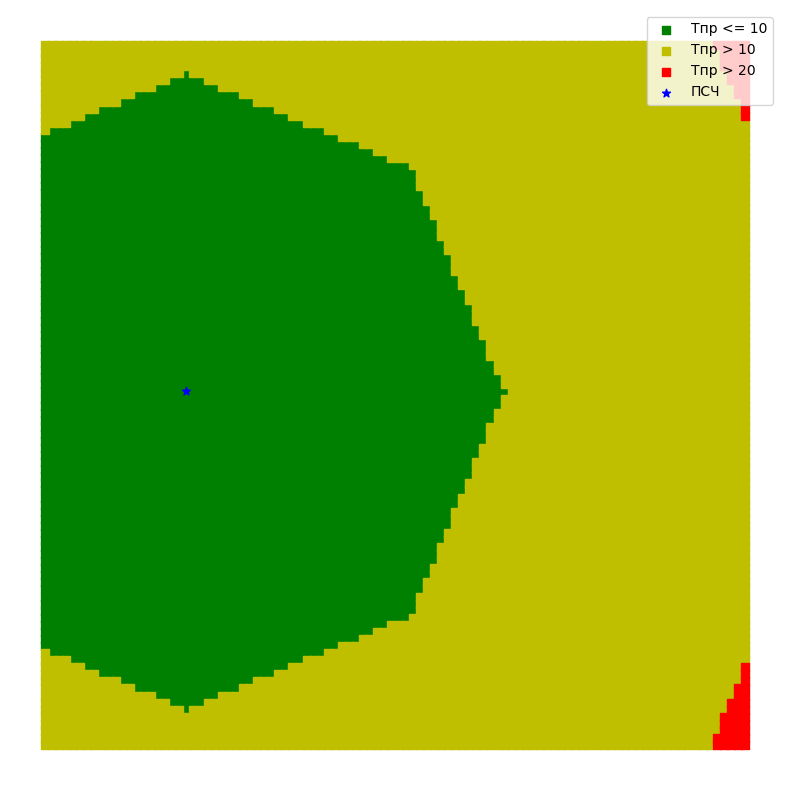

     Среднее время прибытия:  10.7 мин.
Максимальное время прибытия:  20.9 мин.
                      ИП-10:  45.36 %
                      ИП-10:  99.35 %


In [69]:
G = generate_grid_graph(n=100, m=100, step=100.0, speed=30.0, diagonals=True)

units = {
    2050: 'ПСЧ-1',
    # 7020: 'ПСЧ-2',
    }

times, _ = FirstArrivalUnitState()(G, units)

g_nodes = ox.graph_to_gdfs(G, nodes=True, edges=False)
g_nodes['arrival_time'] = times

print_results(g_nodes, units, figsize=(10, 10))

# Пример 3. Квадратный граф с диагоналями и разными скоростями 

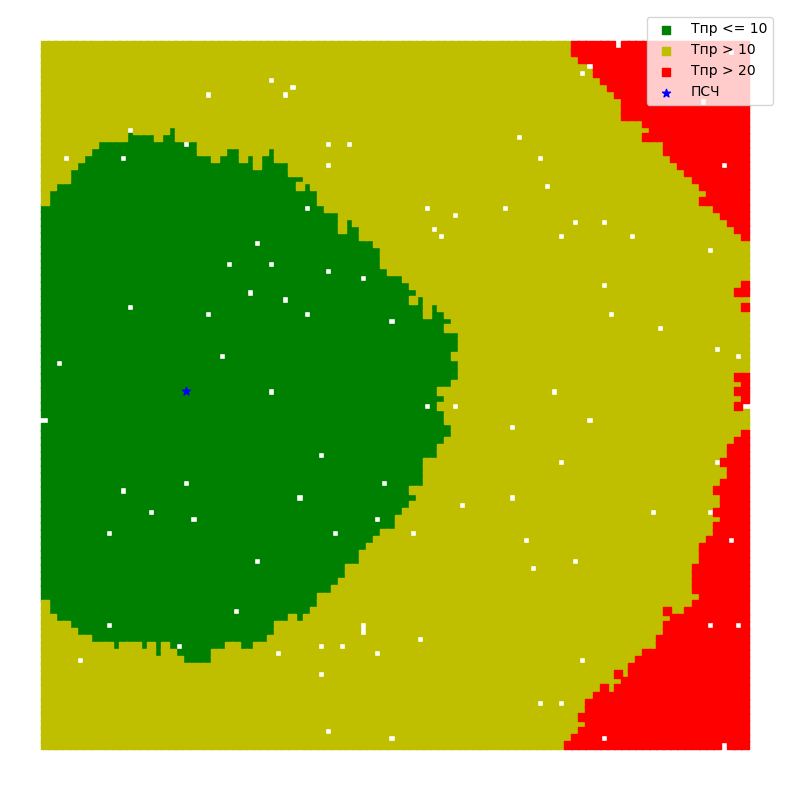

     Среднее время прибытия:  12.6 мин.
Максимальное время прибытия:  25.1 мин.
                      ИП-10:  33.717171717171716 %
                      ИП-10:  91.22222222222223 %


In [70]:
speed = (
    (10,  20,  30,  40),
    (0.2, 0.2, 0.4, 0.2)
)
G = generate_grid_graph(n=100, m=100, step=100.0, speed=speed, diagonals=False)
G = remove_random_elements(G, remove_nodes=100, remove_edges=1000)

units = {
    2050: 'ПСЧ-1',
    # 7020: 'ПСЧ-2',
    }

times, _ = FirstArrivalUnitState()(G, units)

g_nodes = ox.graph_to_gdfs(G, nodes=True, edges=False)
g_nodes['arrival_time'] = times

print_results(g_nodes, units)

# Пример 4. Поиск лучшего размещения

In [71]:
from genesis.best_points import BestNodesFull
from genesis.utils import Progressbar

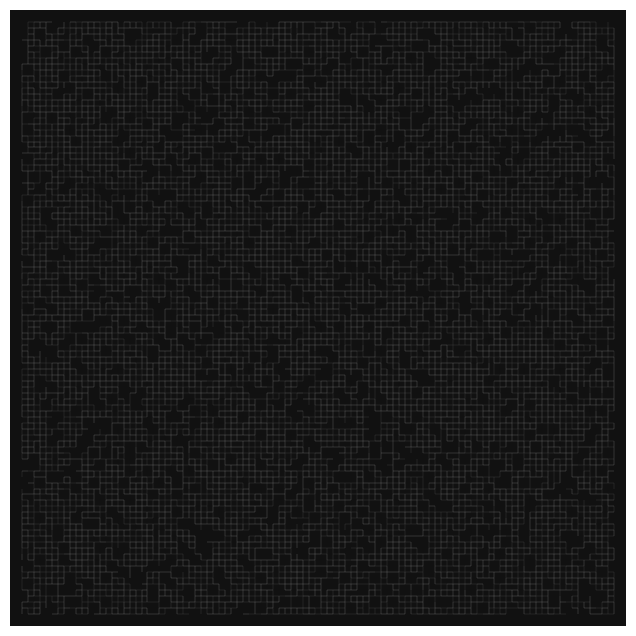

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [91]:
G = generate_grid_graph(n=100, m=100, step=100.0, speed=speed, diagonals=False)
G = remove_random_elements(G,
                remove_nodes=int(G.number_of_nodes()*0.1),
                remove_edges=int(G.number_of_edges()*0.2))
ox.plot_graph(G, node_size=0, edge_linewidth=0.1)

### Полный перебор

|########################################| 100.0%
Результат: 5547 13.740044449509918


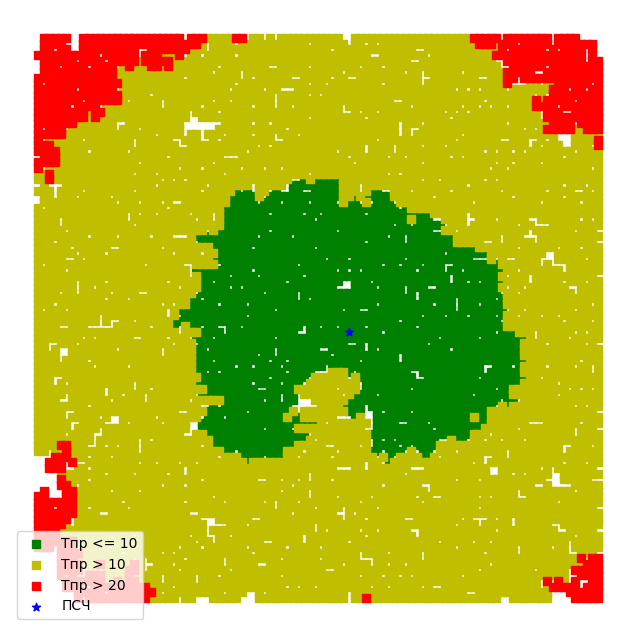

     Среднее время прибытия:  13.7 мин.
Максимальное время прибытия:  25.4 мин.
                      ИП-10:  21.955555555555556 %
                      ИП-10:  90.0111111111111 %


In [99]:
state = FirstArrivalUnitState()
metric = ArrivalTime()

pb = Progressbar(G.number_of_nodes())

blp_full = BestNodesFull(state,
                        metric,
                        node_calc_end_function = pb
                        )
best_nodes, best_metric = blp_full(env=G)
print('Результат:', best_nodes, best_metric)

# Оценка результата
times, _ = FirstArrivalUnitState()(G, {best_nodes: 'full'})

g_nodes = ox.graph_to_gdfs(G, nodes=True, edges=False)
g_nodes['arrival_time'] = times

print_results(g_nodes, {best_nodes: 'full'}, figsize=(8,8))

<Axes: >

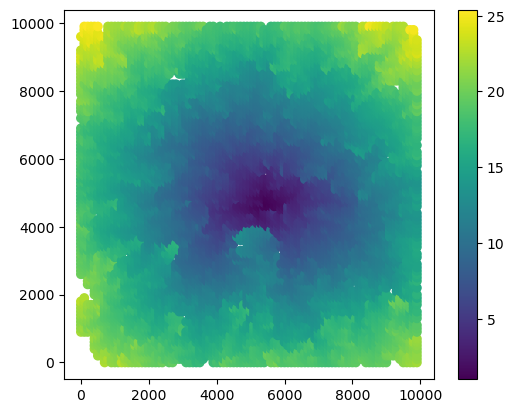

In [100]:
g_nodes.plot(column='arrival_time', legend=True)

### Скалолаз

In [76]:
from genesis.best_points import BestNodeHillClimbing

Результат: 1919 19.17547868702985


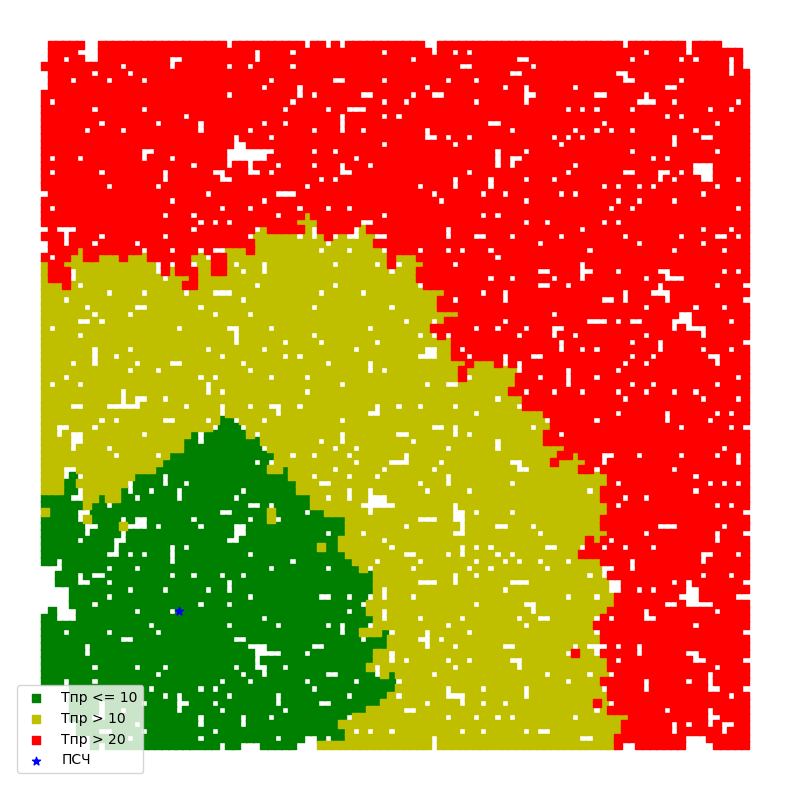

     Среднее время прибытия:  19.2 мин.
Максимальное время прибытия:  38.8 мин.
                      ИП-10:  16.733333333333334 %
                      ИП-10:  49.46666666666667 %


In [101]:
# G = generate_grid_graph(n=100, m=100, step=100.0, speed=30.0, diagonals=True)
# G = generate_grid_graph(n=100, m=100, step=100.0, speed=speed, diagonals=False)
# G = remove_random_elements(G,
#                 remove_nodes=int(G.number_of_nodes()*0.1),
#                 remove_edges=int(G.number_of_edges()*0.2))

hill_climber = BestNodeHillClimbing(state,
                        metric,
                        )

best_nodes, best_metric = hill_climber(env=G)
print('Результат:', best_nodes, best_metric)

# Оценка результата
times, _ = FirstArrivalUnitState()(G, {best_nodes: 'full'})

g_nodes = ox.graph_to_gdfs(G, nodes=True, edges=False)
g_nodes['arrival_time'] = times

print_results(g_nodes, {best_nodes: 'full'}, figsize=(10,10))

Результат: 1919 19.17547868702985


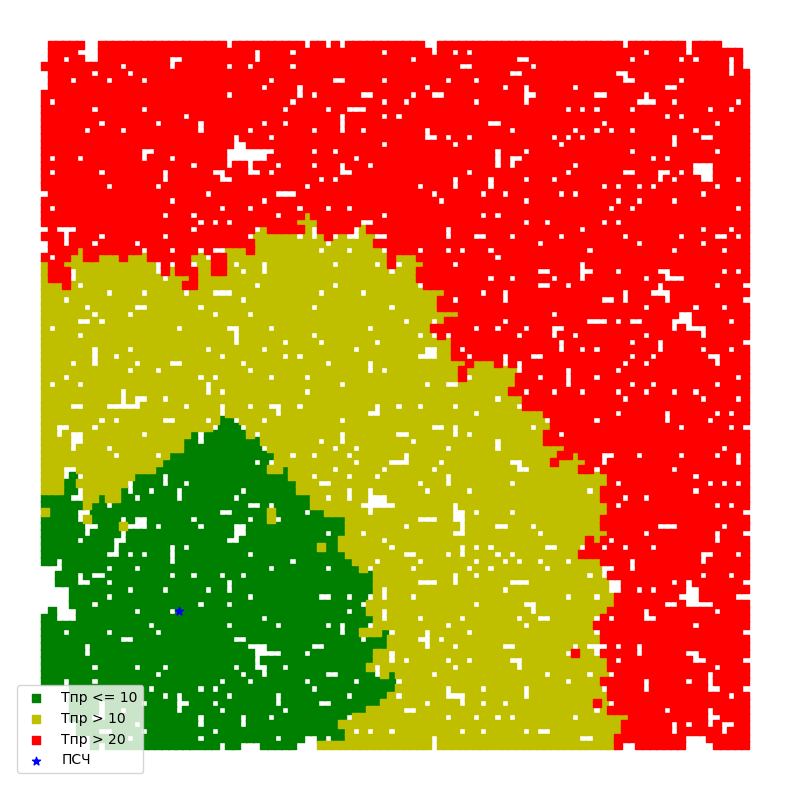

     Среднее время прибытия:  19.2 мин.
Максимальное время прибытия:  38.8 мин.
                      ИП-10:  16.733333333333334 %
                      ИП-10:  49.46666666666667 %


In [102]:
best_nodes, best_metric = hill_climber(env=G)
print('Результат:', best_nodes, best_metric)

# Оценка результата
times, _ = FirstArrivalUnitState()(G, {best_nodes: 'full'})

g_nodes = ox.graph_to_gdfs(G, nodes=True, edges=False)
g_nodes['arrival_time'] = times

print_results(g_nodes, {best_nodes: 'full'}, figsize=(10,10))

### Обезьяний поиск

0 15.648729344729341
-1 14.446119215865053
-1 14.11086163665375
0 14.11086163665375
1 14.11086163665375
2 14.11086163665375
-1 13.96636083884203
-1 13.834391383633461
0 13.834391383633461
-1 13.808399817643034
0 13.808399817643034
1 13.808399817643034
2 13.808399817643034
3 13.808399817643034
4 13.808399817643034
0 13.808399817643034
1 13.808399817643034
2 13.808399817643034
3 13.808399817643034
4 13.808399817643034
0 13.808399817643034
1 13.808399817643034
2 13.808399817643034
3 13.808399817643034
4 13.808399817643034
Результат: 5161 13.808399817643034


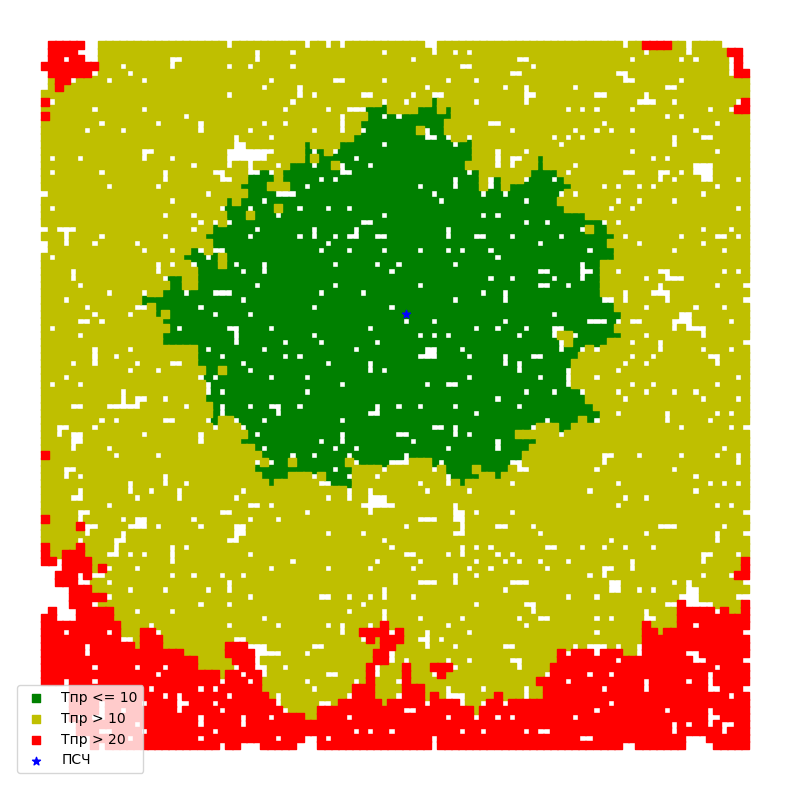

     Среднее время прибытия:  13.8 мин.
Максимальное время прибытия:  26.1 мин.
                      ИП-10:  23.72222222222222 %
                      ИП-10:  84.44444444444444 %


In [103]:
from genesis.best_points import BestNodeMonkey

msa = BestNodeMonkey(state, metric,
            local_jumps_count = 5,
            after_local_jump_function=lambda **kwarg: print(kwarg['local_jump_number'], kwarg['best_metric'])
            )
best_nodes, best_metric = msa(env=G)
print('Результат:', best_nodes, best_metric)

# Оценка результата
times, _ = FirstArrivalUnitState()(G, {best_nodes: 'full'})

g_nodes = ox.graph_to_gdfs(G, nodes=True, edges=False)
g_nodes['arrival_time'] = times

print_results(g_nodes, {best_nodes: 'full'}, figsize=(10,10))

-1 13.834391383633461
0 13.834391383633461
1 13.834391383633461
2 13.834391383633461
3 13.834391383633461
4 13.834391383633461
0 13.834391383633461
1 13.834391383633461
2 13.834391383633461
3 13.834391383633461
4 13.834391383633461
0 13.834391383633461
1 13.834391383633461
2 13.834391383633461
3 13.834391383633461
4 13.834391383633461
Результат: 4358 13.834391383633461


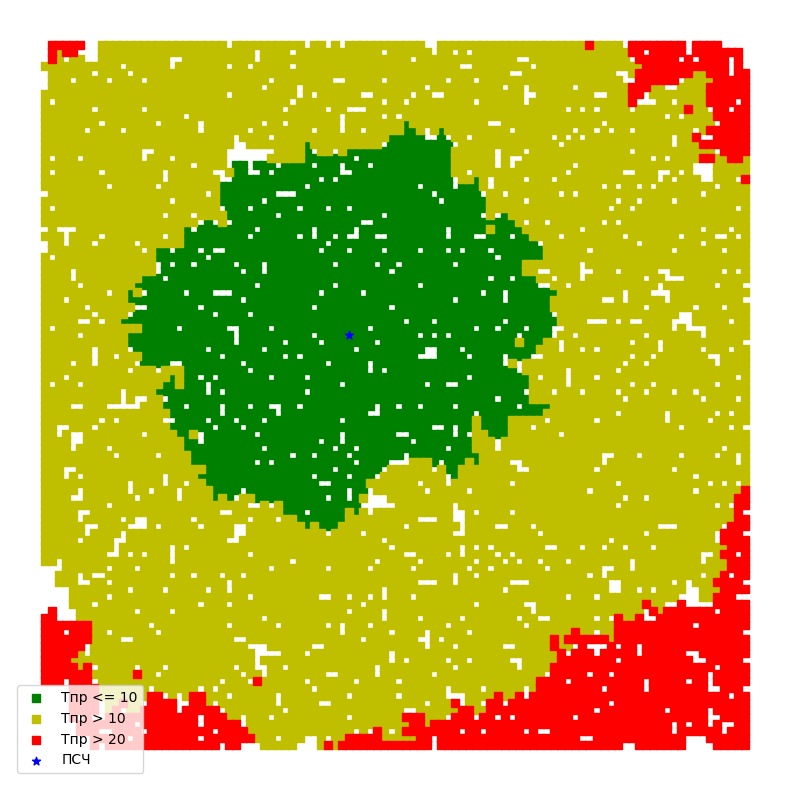

     Среднее время прибытия:  13.8 мин.
Максимальное время прибытия:  27.6 мин.
                      ИП-10:  23.066666666666666 %
                      ИП-10:  86.58888888888889 %


In [104]:
best_nodes, best_metric = msa(env=G)
print('Результат:', best_nodes, best_metric)

# Оценка результата
times, _ = FirstArrivalUnitState()(G, {best_nodes: 'full'})

g_nodes = ox.graph_to_gdfs(G, nodes=True, edges=False)
g_nodes['arrival_time'] = times

print_results(g_nodes, {best_nodes: 'full'}, figsize=(10,10))